# Module 1: Baseline Duration Prediction Model

This notebook builds a baseline ML model for predicting NYC taxi trip duration.
It represents **MLOps Maturity Level 0** — a working model in a notebook with no
experiment tracking, no pipeline, and no deployment.

We'll fix all of that in subsequent modules.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Data

In [2]:
df_train = pd.read_parquet('../../data/raw/yellow_tripdata_2023-01.parquet')
df_val   = pd.read_parquet('../../data/raw/yellow_tripdata_2023-02.parquet')

print(f'Train shape: {df_train.shape}')
print(f'Val shape:   {df_val.shape}')
df_train.head()

Train shape: (3066766, 19)
Val shape:   (2913955, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


## 3. Exploratory Data Analysis

In [3]:
print('Column names:')
print(df_train.columns.tolist())
print()
print('dtypes:')
print(df_train.dtypes)
print()
print('Nulls:')
print(df_train.isnull().sum())

Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amou

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
RatecodeID               71743
store_and_fwd_flag       71743
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     71743
airport_fee              71743
dtype: int64


In [4]:
# Compute trip duration in minutes
df_train['duration'] = (
    df_train.tpep_dropoff_datetime - df_train.tpep_pickup_datetime
).dt.total_seconds() / 60

df_val['duration'] = (
    df_val.tpep_dropoff_datetime - df_val.tpep_pickup_datetime
).dt.total_seconds() / 60

print('Duration stats (minutes):')
print(df_train['duration'].describe())

Duration stats (minutes):


count    3.066766e+06
mean     1.566900e+01
std      4.259435e+01
min     -2.920000e+01
25%      7.116667e+00
50%      1.151667e+01
75%      1.830000e+01
max      1.002918e+04
Name: duration, dtype: float64


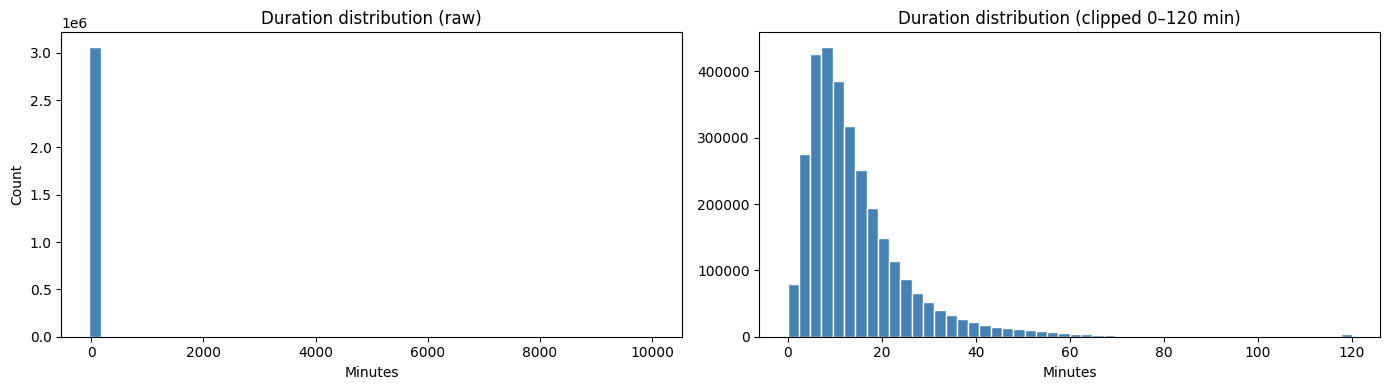

Plot saved ✅


In [5]:
# Plot duration distribution before filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_train['duration'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Duration distribution (raw)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

axes[1].hist(df_train['duration'].clip(0, 120), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Duration distribution (clipped 0–120 min)')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.savefig('../../data/processed/duration_distribution.png', dpi=100)
plt.show()
print('Plot saved ✅')

## 4. Data Preparation & Feature Engineering

In [6]:
def prepare_features(df, categorical, target='duration'):
    """Filter outliers and encode categorical features."""
    df = df.copy()

    # Compute duration if not already present
    if 'duration' not in df.columns:
        df['duration'] = (
            df.tpep_dropoff_datetime - df.tpep_pickup_datetime
        ).dt.total_seconds() / 60

    # Filter to reasonable trip durations
    df = df[(df.duration >= 1) & (df.duration <= 60)]
    print(f'  Rows after filtering: {len(df):,}')

    # Cast location IDs to string for DictVectorizer
    df[categorical] = df[categorical].astype(str)

    return df


categorical = ['PULocationID', 'DOLocationID']
numerical   = ['trip_distance']

print('Preparing training data...')
df_train_clean = prepare_features(df_train, categorical)

print('Preparing validation data...')
df_val_clean = prepare_features(df_val, categorical)

Preparing training data...


  Rows after filtering: 3,009,173


Preparing validation data...


  Rows after filtering: 2,855,951


In [7]:
# Encode features
dv = DictVectorizer()

train_dicts = df_train_clean[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val_clean[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_train = df_train_clean['duration'].values
y_val   = df_val_clean['duration'].values

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')

X_train shape: (3009173, 516)
X_val shape:   (2855951, 516)


## 5. Model Training & Evaluation

In [8]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Fit model and report RMSE on train and val."""
    model.fit(X_tr, y_tr)
    rmse_train = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
    rmse_val   = np.sqrt(mean_squared_error(y_v,  model.predict(X_v)))
    print(f'{name:<25}  train RMSE: {rmse_train:.3f}  |  val RMSE: {rmse_val:.3f}')
    return model, rmse_train, rmse_val


models = {
    'LinearRegression':  LinearRegression(),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
}

results = {}
for name, model in models.items():
    trained_model, rmse_tr, rmse_v = evaluate_model(
        name, model, X_train, y_train, X_val, y_val
    )
    results[name] = {'model': trained_model, 'train_rmse': rmse_tr, 'val_rmse': rmse_v}

LinearRegression           train RMSE: 7.658  |  val RMSE: 7.820


Lasso (alpha=0.1)          train RMSE: 8.599  |  val RMSE: 8.750


Ridge (alpha=1.0)          train RMSE: 7.651  |  val RMSE: 7.813


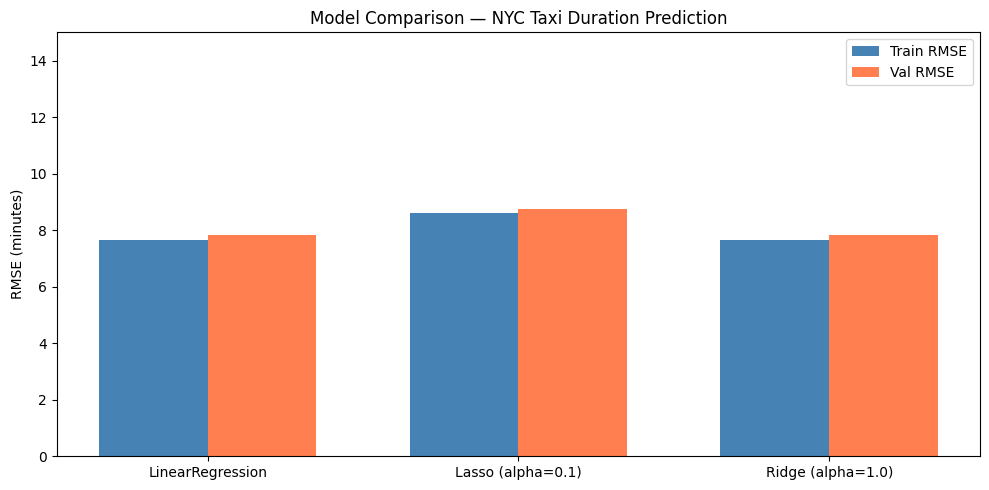

Plot saved ✅


In [9]:
# Plot RMSE comparison
model_names = list(results.keys())
train_rmses = [results[m]['train_rmse'] for m in model_names]
val_rmses   = [results[m]['val_rmse']   for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, train_rmses, width, label='Train RMSE', color='steelblue')
ax.bar(x + width/2, val_rmses,   width, label='Val RMSE',   color='coral')

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('RMSE (minutes)')
ax.set_title('Model Comparison — NYC Taxi Duration Prediction')
ax.legend()
ax.set_ylim(0, 15)

plt.tight_layout()
plt.savefig('../../data/processed/model_comparison.png', dpi=100)
plt.show()
print('Plot saved ✅')

## 6. Key Observations & What's Missing

### Results summary
- Linear Regression performs best — taxi duration is a fairly linear problem
- All models have similar train/val RMSE, suggesting no significant overfitting
- An RMSE of ~7–8 minutes is a reasonable baseline

### What this notebook is missing (MLOps gaps)
| Gap | Fix in Module |
|-----|---------------|
| No experiment tracking — can't compare runs | Module 2: MLflow |
| Manual, notebook-based workflow | Module 3: Orchestration |
| No way to serve predictions | Module 4: Deployment |
| No monitoring for drift | Module 5: Monitoring |
| No tests or CI/CD | Module 6: Best practices |

Next: **Module 2** — wrap this in MLflow to track every run automatically.